In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

viridis_colors = cm.viridis(np.linspace(0, 1, 5))
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = '#800000'
neutral_color = viridis_colors[4]
custom_palette = viridis_colors

In [3]:
df = pd.read_csv('/content/DataCoSupplyChainDataset.csv', encoding='latin1')
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/15/2018 11:24,Standard Class


In [4]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

# **Exploratory Data Analysis**

In [5]:
df.shape

(8002, 53)

In [6]:
print('rows, cols:', df.shape)
print('\ncolumns:')
print(df.columns.tolist())
print('\nNum Duplicates:' , df.duplicated().sum())
print('\nNum Missing Values (top 20) :')
print(df.isnull().sum().sort_values(ascending=False).head(20))

rows, cols: (8002, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product 

In [7]:
(df['Product Status']).value_counts()

,count
Product Status,
0.0,8001


In [8]:
columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer LName',
    'Customer City',
    'Order Item',
    'Customer FName',
    'Customer Zipcode',
    'Latitude',
    'Longitude',
    'Order Zipcode',
    'Customer Address',
    'Customer Phone',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',
    'Product Status',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
]

# remove duplicates (optional but clean)
columns_to_drop = list(set(columns_to_drop))

df = df.drop(columns=columns_to_drop, errors='ignore')

df = df[df['Delivery Status'] != 'Shipping canceled']

for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors='coerce', dayfirst=False)

print('rows, cols:', df.shape)
print('\nNum Missing Values (top 5) :')
print(df.isnull().sum().sort_values(ascending=False).head(5))

rows, cols: (7680, 24)

Num Missing Values (top 5) :
Sales                     1
Order Profit Per Order    1
Order Region              1
Order Status              1
Product Name              1
dtype: int64


In [9]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Fname,Customer Lname,...,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Cally,Holloway,...,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Irene,Luna,...,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Gillian,Maldonado,...,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Tana,Tate,...,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Orli,Hendricks,...,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [10]:
for col in df.columns:
  if df[col].nunique() < 10:
    print(f'\n{col} value counts:')
    print(df[col].value_counts())


Type value counts:
Type
DEBIT       3166
PAYMENT     1615
TRANSFER    1592
CASH        1307
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    2208
4    1390
6    1347
3    1310
5    1286
1      81
0      58
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    4602
2    2062
1     877
0     139
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery       4438
Advance shipping    1827
Shipping on time    1415
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    4438
0    3242
Name: count, dtype: int64

Customer Country value counts:
Customer Country
Puerto Rico    4159
EE. UU.        3521
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       3819
Corporate      2324
Home Office    1537
Name: count, dtype: int64

Market value counts:
Market
Pacific Asia    2525
LATAM           2040
Europe     

In [11]:
df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']
df['Is_Delayed'] = df['Delay'] > 0
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,7680.000000,7680.000000,7680.000000,7680.000000,7679,7679.000000,7679.000000,7679.000000,7679.000000,7679,7679.000000,7679.000000,7679.000000,7679.000000
mean,3.710807,3.048047,178.134824,0.577865,2016-06-21 09:55:24.721968896,0.117638,198.770417,21.615622,121.724051,2016-06-25 02:56:34.574814464,3.700091,0.652168,6.338456,11.441073
min,0.000000,0.000000,8.470000,0.000000,2015-01-01 03:51:00,-2.750000,11.290000,-1140.790039,11.290000,2015-01-04 03:51:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,97.957499,0.000000,2015-09-27 19:25:00,0.070000,110.000000,6.140000,50.000000,2015-10-01 08:33:00,2.000000,0.000000,3.000000,5.000000
50%,4.000000,4.000000,149.074997,1.000000,2016-05-09 14:43:00,0.270000,159.960007,29.309999,59.990002,2016-05-13 12:47:00,4.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,251.979996,1.000000,2017-03-18 02:22:00,0.360000,299.950012,63.150002,129.990005,2017-03-22 15:20:00,5.000000,2.000000,10.000000,17.000000
max,6.000000,4.000000,1470.000000,1.000000,2018-01-31 22:56:00,0.500000,1500.000000,599.250000,1500.000000,2018-02-05 14:43:00,6.000000,4.000000,12.000000,23.000000
std,1.523814,1.218710,118.456316,0.493932,NaN,0.464189,131.754753,99.563746,130.990895,NaN,1.545874,1.584387,3.702033,6.927837


In [12]:
df['Is_Delayed'].value_counts()

,count
Is_Delayed,
True,4356
False,3324


In [13]:
df['Probability Flag'] = np.where(df['Order Profit Per Order'] > 0, 'Profit', np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Break-even'))
df['Probability Flag'].value_counts()

,count
Probability Flag,
Profit,6176
Loss,1457
Break-even,47


In [14]:
df['Probability Flag'].value_counts(normalize=True)

,proportion
Probability Flag,
Profit,0.804167
Loss,0.189714
Break-even,0.006120


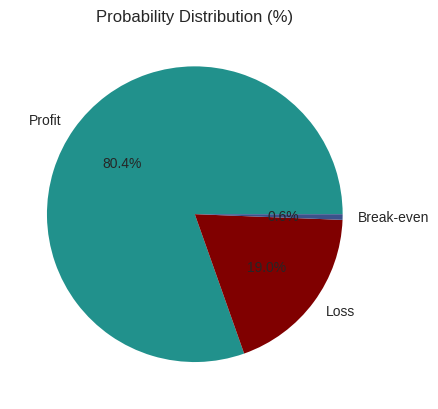

In [15]:
#visualization of probability
profit_counts = df['Probability Flag'].value_counts(normalize=True) * 100
profit_counts.plot(kind='pie', autopct='%1.1f%%', colors=[accent_color, danger_color, secondary_color])
plt.ylabel('')
plt.title('Probability Distribution (%)')
plt.show()

In [16]:
def format_func(value):
  if value >= 1e6:
    return f'{value/1e6:.1f}M $'

  elif value >= 1e3:
    return f'{value/1e3:.1f}K $'

  else:
    return f'{value:.0f} $'

delayed_df = df[df['Delay'] > 0]
metrics = {}
metrics ['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %'] = (1 - float(metrics['Late Deliveries']) / metrics['Total Orders']) * 100
metrics['Late Delivery %'] = float(metrics['Late Deliveries']) / metrics['Total Orders'] * 100
metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum())
metrics['Total Loss Due to delays'] = format_func(df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum())

print('\n---------Business KPIs---------\n')
for k, v in metrics.items():
  if isinstance(v, float):
    print(f"{k}: {v:.2f}")
  else:
    print(f"{k}: {v}")


---------Business KPIs---------

Total Orders: 7680
Late Deliveries: 4356
90% Delay (days): 3.50
On time Delivery %: 43.28
Late Delivery %: 56.72
Total Profit: 324.4K $
Total Loss Due to delays: 88.9K $


# **Profability vs Delivery Time Analysis**

In [17]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
    .agg(
        mean_profit = 'mean',
        median_profit = 'median',
        max_profit = 'max',
    )
    .reset_index()
)

In [18]:
profit_metrics

,Delay,mean_profit,median_profit,max_profit
0,-2.0,28.717225,31.035001,599.250000
1,-1.0,22.061277,32.340000,529.200012
2,0.0,20.443128,28.804999,435.600006
3,1.0,22.348985,28.840000,410.850006
4,2.0,18.028910,28.219999,227.929993
5,3.0,20.092781,26.730000,595.349976
6,4.0,18.343257,25.780000,466.880005


In [19]:
delay_distribution = (
    df['Delay']
    .value_counts(normalize=True)
    .sort_values() * 100

).reset_index()

In [20]:
delay_distribution

,Delay,proportion
0,3.0,4.870426
1,4.0,5.677823
2,-1.0,11.733299
3,-2.0,12.058862
4,2.0,17.567392
5,0.0,19.481703
6,1.0,28.610496



Profit Metrics by Delay Day:


,Delay,mean_profit,median_profit,max_profit
0,-2.0,28.7,31.0,599.2
1,-1.0,22.1,32.3,529.2
2,0.0,20.4,28.8,435.6
3,1.0,22.3,28.8,410.9
4,2.0,18.0,28.2,227.9
5,3.0,20.1,26.7,595.3
6,4.0,18.3,25.8,466.9



Delay Distribution (%):


,Delay_Days,Percentage
0,3.0,4.870426
1,4.0,5.677823
2,-1.0,11.733299
3,-2.0,12.058862
4,2.0,17.567392
5,0.0,19.481703
6,1.0,28.610496


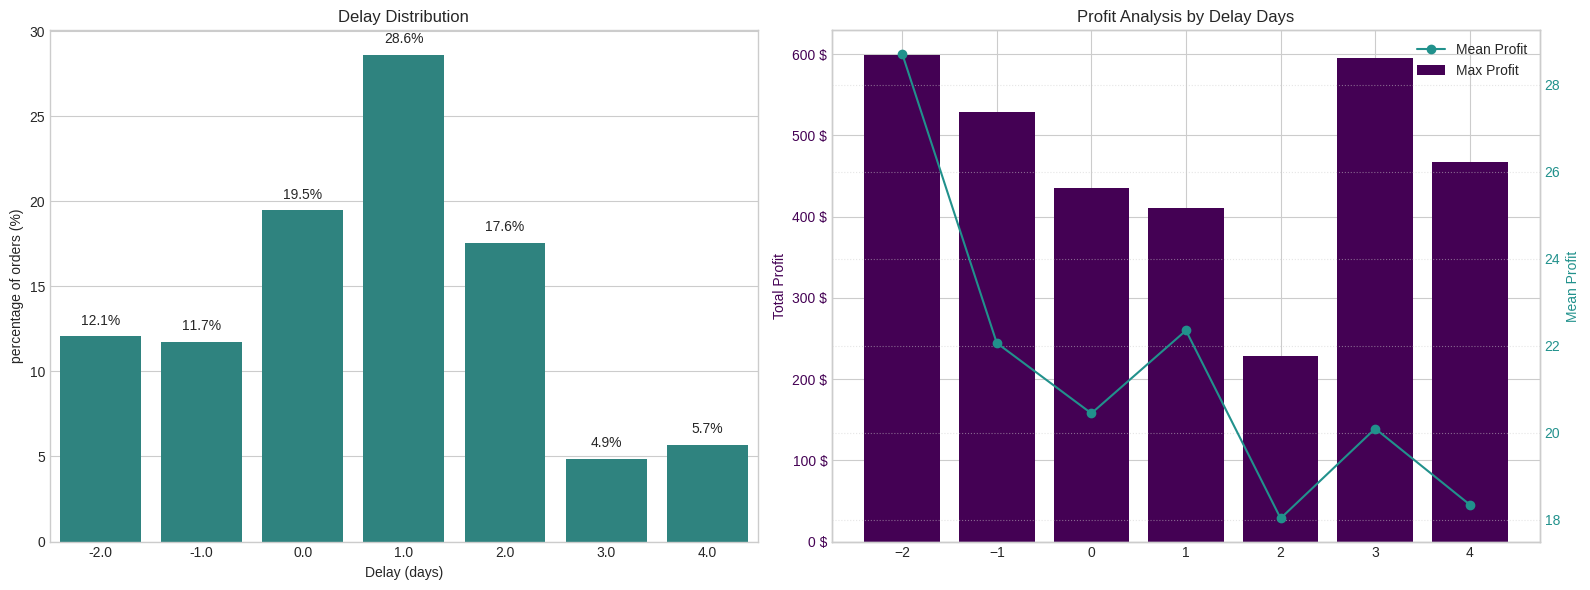

In [21]:
delay_distribution.columns = ['Delay_Days', 'Percentage']

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# First subplot: Delay Distribution
sns.barplot(x='Delay_Days', y='Percentage', data=delay_distribution, color=accent_color, ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('percentage of orders (%)')

# percentage text on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom')

# Second subplot: Profit Analysis by Delay Days
ax2.set_ylabel("Total Profit", color=primary_color)

ax2.bar(
    profit_metrics['Delay'],          # ✅ FIXED
    profit_metrics['max_profit'],
    color=primary_color,
    label='Max Profit'
)

ax2.tick_params(axis='y', labelcolor=primary_color)

ax3 = ax2.twinx()

ax3.set_xlabel("Delay (days)")
ax3.set_ylabel("Mean Profit", color=accent_color)

ax3.plot(
    profit_metrics['Delay'],          # ✅ FIXED
    profit_metrics['mean_profit'],
    marker='o',
    label='Mean Profit',
    color=accent_color
)

ax3.tick_params(axis='y', labelcolor=accent_color)

def format_func(value, tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

ax3.set_title("Profit Analysis by Delay Days")

lines, labels = ax3.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

ax3.grid(True, linestyle=':', alpha=0.5)   # ✅ FIXED

plt.tight_layout()
plt.show()

#**Bottleneck Detection**

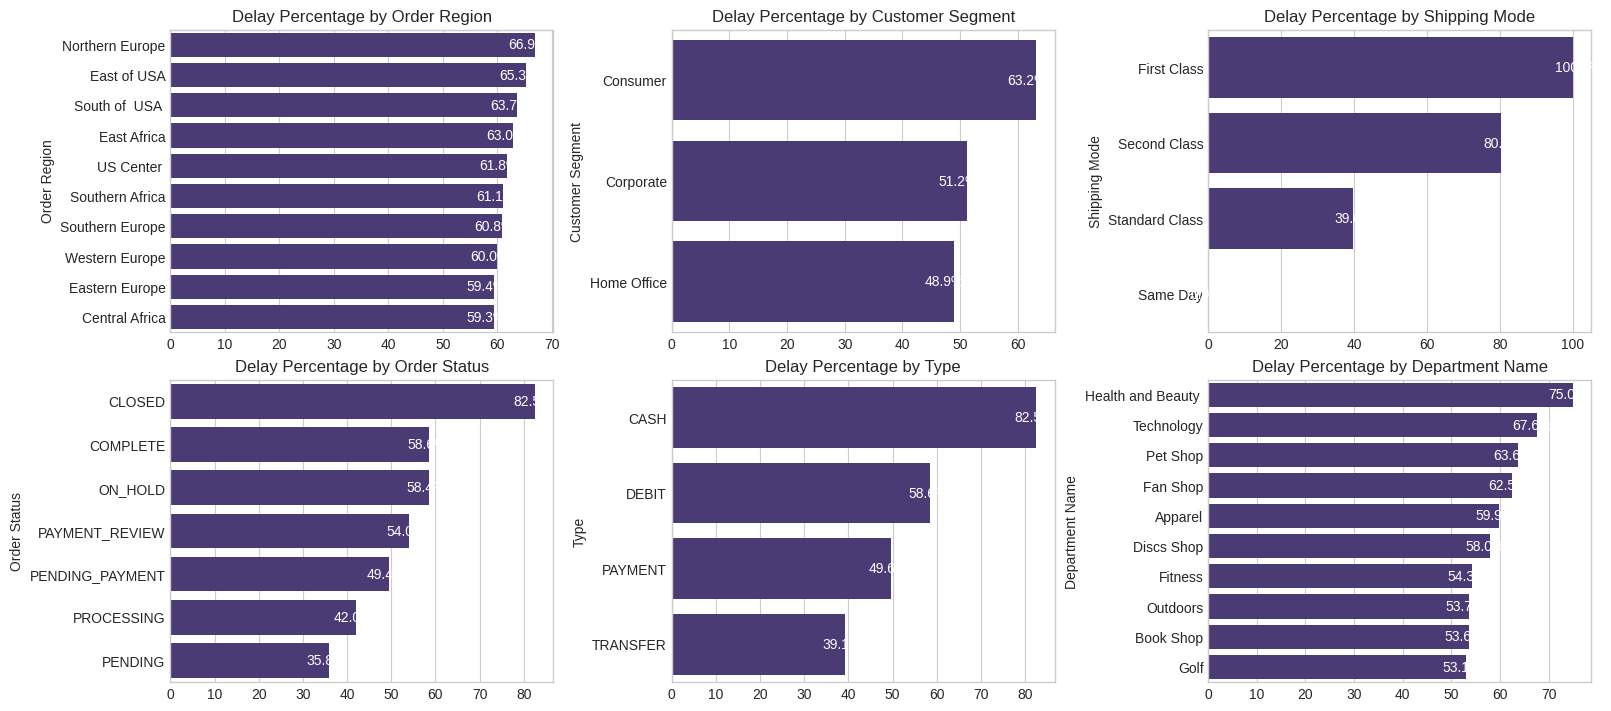

In [22]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()

    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)

    return cat_df


categories = [
    'Order Region',
    'Customer Segment',
    'Shipping Mode',
    'Order Status',
    'Type',
    'Department Name'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)

    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax
    )

    ax.set_title(f'Delay Percentage by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)

    for p in ax.patches:
        width = p.get_width()
        ax.text(
            width - 5,
            p.get_y() + p.get_height() / 2,
            f"{width:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )

# **Root Cause Analysis**

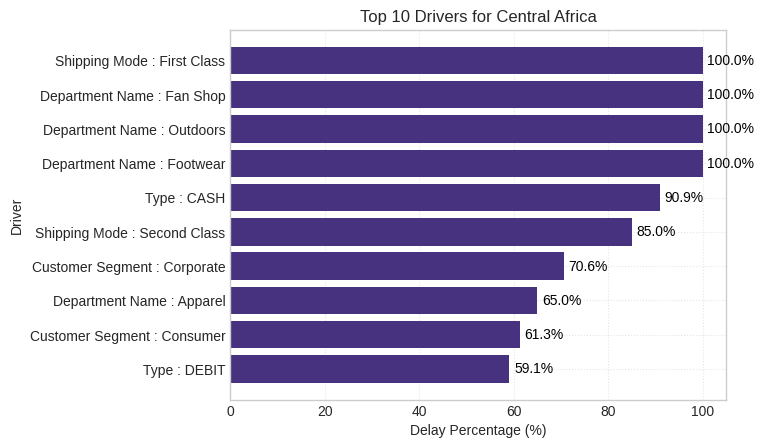

In [23]:
def top_drivers_for_region(Region):
    df_region = df[df['Order Region'] == Region].copy()

    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name', 'Type']

    all_factors = []
    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean'),
            )
            .reset_index()
        )

        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + ' : ' + temp[factor].astype(str)

        all_factors.append(
            temp[['Driver', 'Factor_Level', 'avg_delay', 'delay_pct', 'total_orders']]
        )

    # combine all drivers
    final_df = pd.concat(all_factors)

    # Top 10 drivers
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)

    plt.figure()

    bars = plt.barh(top_factors['Factor_Level'], top_factors['delay_pct'])

    plt.xlabel('Delay Percentage (%)')
    plt.ylabel('Driver')
    plt.title(f'Top 10 Drivers for {Region}')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()

    for bar in bars:
        width = bar.get_width()
        plt.text(
            width + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va='center',
            fontsize=10,
            color='black'  # changed for visibility
        )

    plt.show()

top_drivers_for_region('Central Africa')

# **Time Based Analysis**

In [24]:
# Delay by Month
delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100


# Delay by Day
delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100


# Delay by Hour
delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

In [25]:
delay_by_month

,order_month,Is_Delayed,delay_pct
0,1.0,0.546296,54.629630
1,2.0,0.541985,54.198473
2,3.0,0.539493,53.949329
3,4.0,0.586806,58.680556
4,5.0,0.594228,59.422750
5,6.0,0.553846,55.384615
6,7.0,0.629630,62.962963
7,8.0,0.625436,62.543554
8,9.0,0.572741,57.274119
9,10.0,0.587922,58.792185


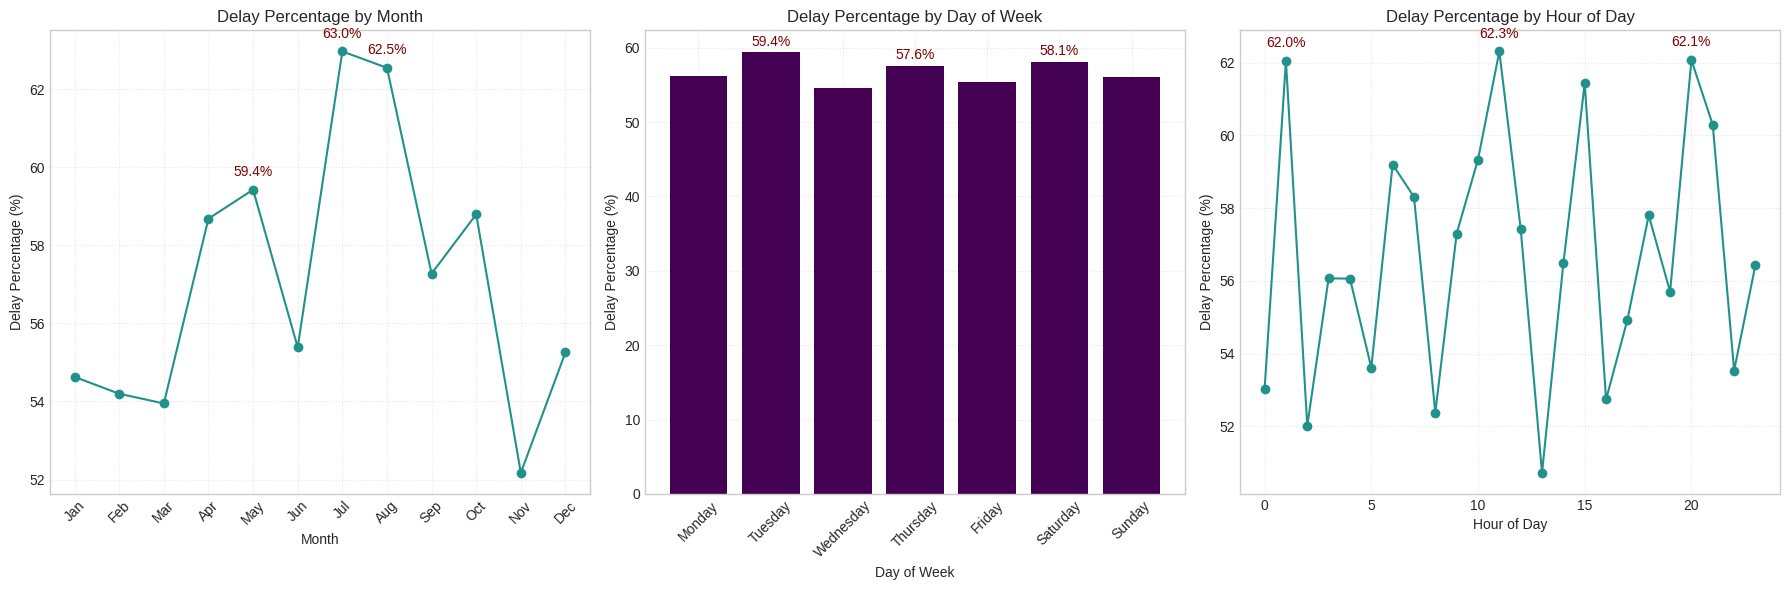

In [26]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: Month
ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'],
         marker='o', color=accent_color)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)

ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay Percentage by Month")
ax1.grid(True, linestyle=':', alpha=0.5)

top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%",
                 (row['order_month'], row['delay_pct']),
                 textcoords="offset points",
                 xytext=(0, 10),
                 ha='center',
                 fontsize=10,
                 color=danger_color)


# Subplot 2: Day
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']

delay_by_day['order_day'] = pd.Categorical(
    delay_by_day['order_day'],
    categories=day_order,
    ordered=True
)

delay_by_day = delay_by_day.sort_values('order_day')

ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'],
        color=primary_color)

ax2.set_xticklabels(delay_by_day['order_day'], rotation=45)

ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay Percentage by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(row['order_day'], height + 0.5,
             f"{height:.1f}%",
             ha='center',
             va='bottom',
             fontsize=10,
             color=danger_color)


# Subplot 3: Hour (OUTSIDE loop)
ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'],
         marker='o', color=accent_color)

ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay Percentage by Hour of Day")
ax3.grid(True, linestyle=':', alpha=0.5)

top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['delay_pct']:.1f}%",
                 (row['order_hour'], row['delay_pct']),
                 textcoords="offset points",
                 xytext=(0, 10),
                 ha='center',
                 fontsize=10,
                 color=danger_color)

plt.tight_layout()
plt.show()

# **Machine Learning Modeling**

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE

In [28]:
X = df[['Type',
        'Days for shipment (scheduled)',
        'Category Name',
        'Department Name',
        'Order Region',
        'Shipping Mode',
        'order_month',
        'order_hour']]

y = df['Late_delivery_risk']

In [31]:
cats_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cats_cols)

# Frequency
for col in cats_cols:
  freq = X[col].value_counts(normalize=True)
  X[f'{col}_freq'] = X[col].map(freq)

x_encoded = X.drop(columns=cats_cols)
print('Shape after freq+target encoding:', x_encoded.shape)
X = x_encoded

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

Categorical columns: []
Shape after freq+target encoding: (7680, 8)


In [32]:
y.value_counts()

,count
Late_delivery_risk,
1,4438
0,3242


In [37]:
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from collections import Counter

# Impute missing values
imputer = SimpleImputer(strategy='mean')  # works now since all are numeric
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed  = imputer.transform(X_test)

# Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_imputed, y_train)

print("Before:", Counter(y_train))
print("After:", Counter(y_train_bal))

Before: Counter({1: 3550, 0: 2594})
After: Counter({1: 3550, 0: 3550})


In [38]:
def evaludate_model(y_true, y_pred, model_name):
  print(f"\n------{model_name}--------")
  print('Accuracy: ', round(accuracy_score(y_true, y_pred),2))
  print('Precision: ', round(precision_score(y_true, y_pred),2))
  print('Recall: ', round(recall_score(y_true, y_pred),2))
  print("\nClassification Report: \n", classification_report(y_true, y_pred))


In [44]:
# Fit the Random Forest Classifier model on balanced data
rf_model_balanced = RandomForestClassifier(random_state=42)
rf_model_balanced.fit(X_train_bal, y_train_bal)

y_pred_balanced = rf_model_balanced.predict(X_test)

evaludate_model(y_test, y_pred_balanced, 'Random Forest Classifier')


------Random Forest Classifier--------
Accuracy:  0.68
Precision:  0.73
Recall:  0.72

Classification Report: 
               precision    recall  f1-score   support

           0       0.62      0.64      0.63       648
           1       0.73      0.72      0.72       888

    accuracy                           0.68      1536
   macro avg       0.68      0.68      0.68      1536
weighted avg       0.69      0.68      0.68      1536

